# Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [5]:
df = pd.read_csv("RF_Social_Network_Ads.csv")

print(df.shape)

df.head(10)

(400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


# Step 3: Basic Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [7]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [8]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

# Step 4: Display Sample Records

In [10]:
df.head(15)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


# Step 5: Target Variable Distribution

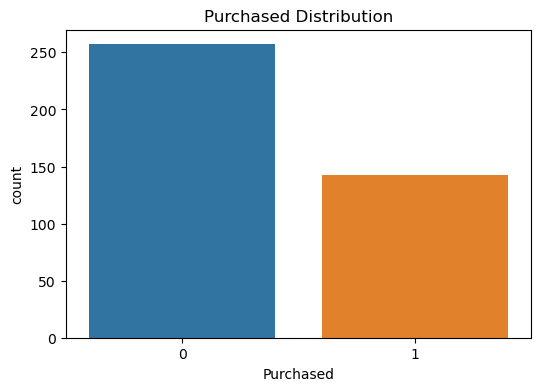

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Purchased',
    data=df
)

plt.title("Purchased Distribution")

plt.show()

# Step 6: Drop User ID

In [12]:
df.drop('User ID', axis = 1, inplace = True)

df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


# Step 7: Encode Gender

In [13]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(
    df['Gender']
)

df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


# Step 8: Correlation Heatmap

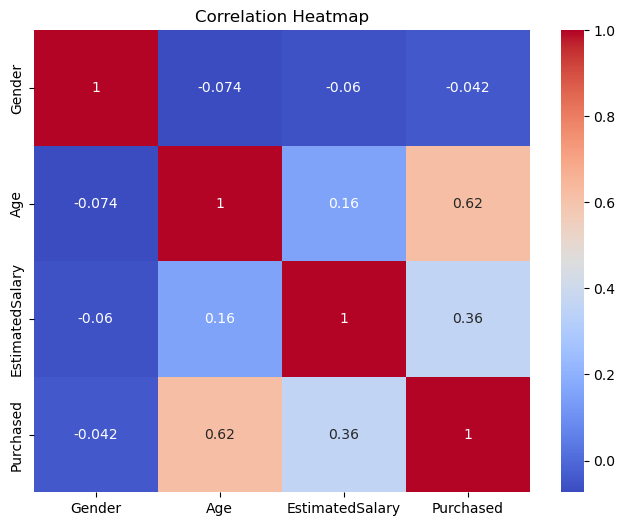

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Step 9: Feature Relationship with Target

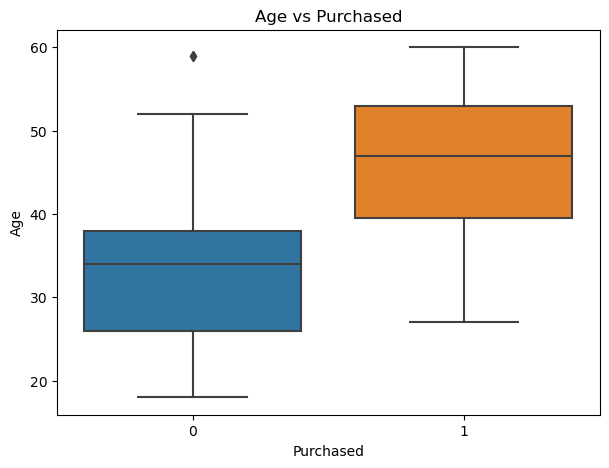

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(x = 'Purchased', y = 'Age', data = df)

plt.title("Age vs Purchased")

plt.show()

# Step 10: Salary vs Purchased

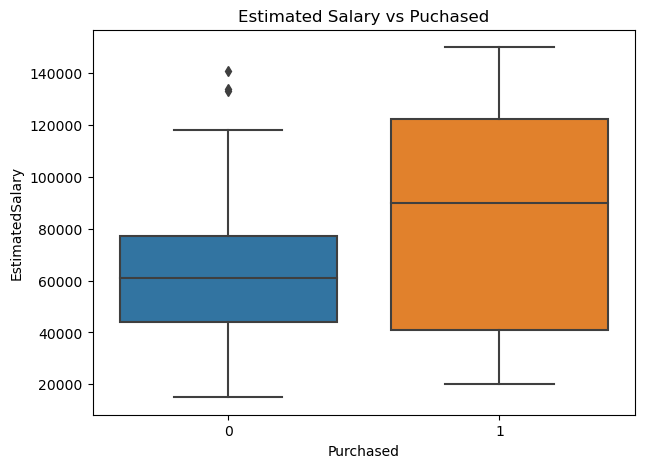

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Purchased',
    y='EstimatedSalary',
    data=df
)

plt.title("Estimated Salary vs Puchased")

plt.show()

# Step 11: Separate Features and Target

In [19]:
X = df.drop('Purchased', axis = 1)
y = df['Purchased']

print(X.shape)
print(y.shape)

(400, 3)
(400,)


# Step 12: Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (320, 3)
Testing Shape : (80, 3)


# Step 13: Build Random Forest Model

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=8, n_estimators=300, random_state=42)

# Step 14: Prediction

In [22]:
y_pred = rf_model.predict(X_test)

print(y_pred[:10])

array([1, 0, 0, 1, 0, 1, 0, 1, 1, 0], dtype=int64)

# Step 15: Accuracy Score

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", round(accuracy*100,2), '%')

Accuracy : 90.0 %


# Step 16: Confusion Matrix

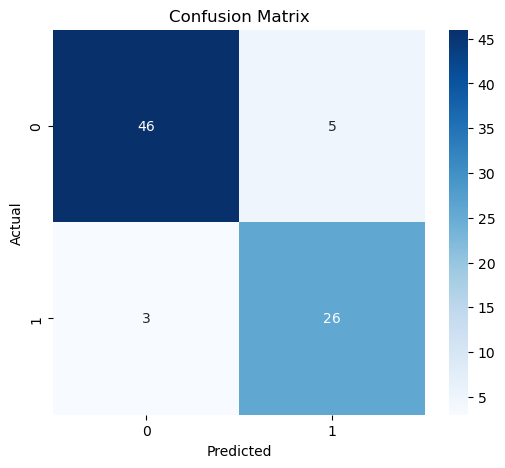

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Step 17: Classification Report

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92        51
           1       0.84      0.90      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.90      0.89        80
weighted avg       0.90      0.90      0.90        80



# Step 18: ROC-AUC Score

In [28]:
y_prob = rf_model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score :", round(auc, 4))

ROC AUC Score : 0.9398


# Step 19: ROC Curve

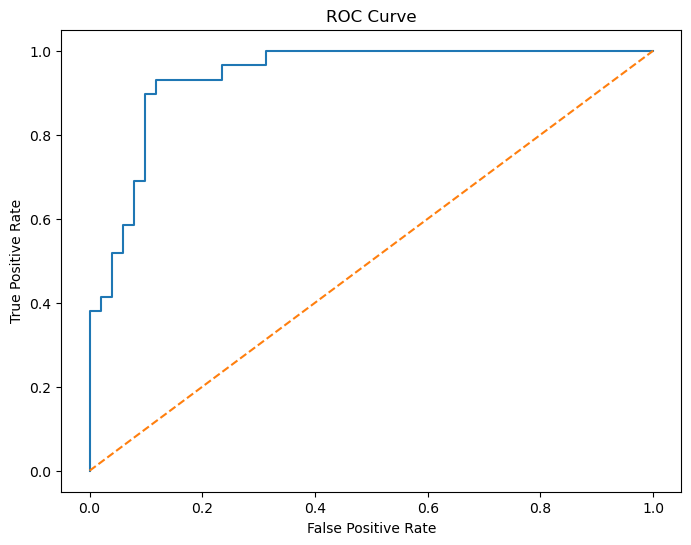

In [29]:
fpr, tpr, threshold = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC={auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

# Step 20: Feature Importance

In [30]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': importance

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
1,Age,0.502693
2,EstimatedSalary,0.488412
0,Gender,0.008895


# Step 21: Feature Importance Graph

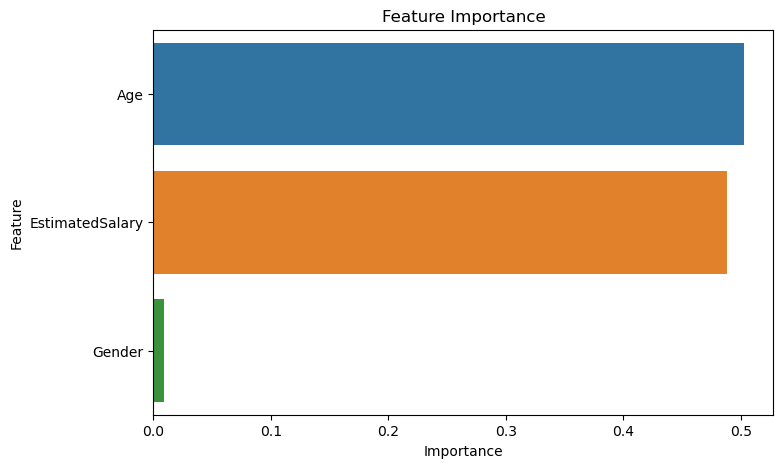

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# Step 22: Actual vs Predicted

In [32]:
comparison = pd.DataFrame({

    'Actual': y_test,
    'Predicted': y_pred

})

comparison.head(20)

,Actual,Predicted
331,1,1
92,0,0
1,0,0
234,0,1
136,0,0
356,1,1
122,0,0
223,1,1
64,0,1
398,0,0


# Step 23: Random Forest Tree Visualization

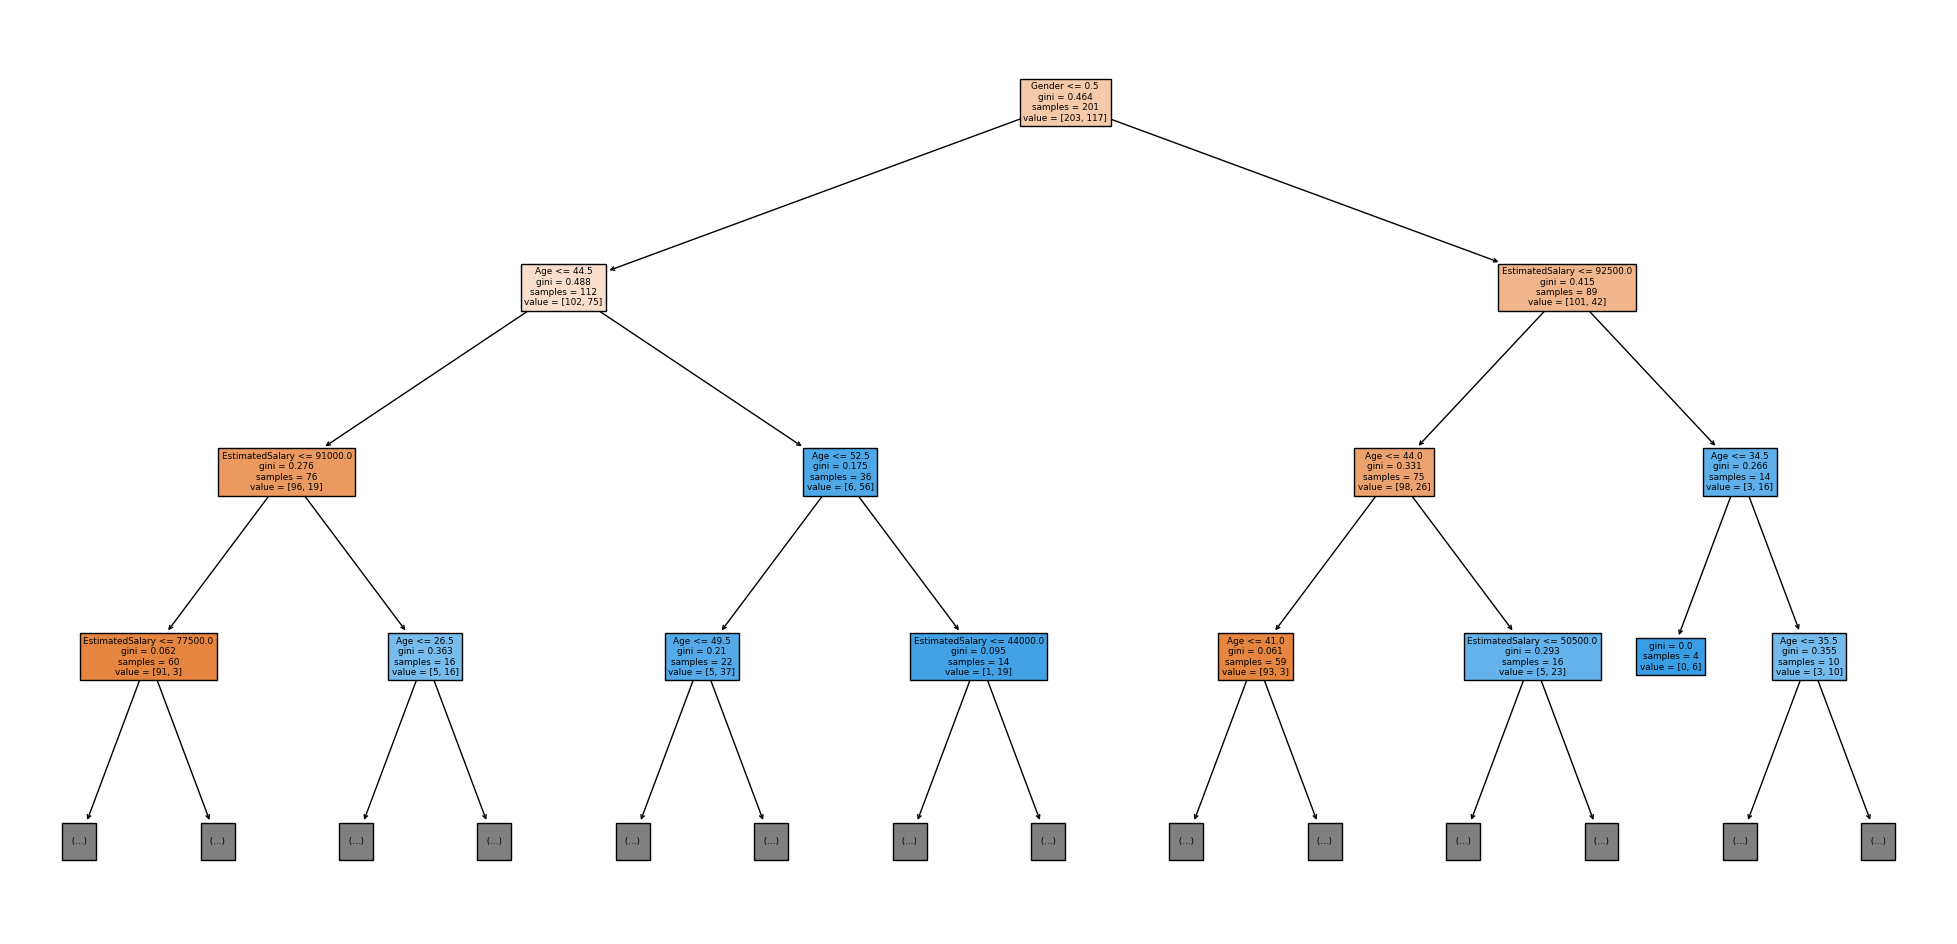

In [34]:
plt.figure(figsize=(25,12))

plot_tree(
    rf_model.estimators_[0],
    feature_names=X.columns,
    filled=True,
    max_depth=3
)

plt.show()

# Step 24: Overfitting Check

In [35]:
train_pred = rf_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

test_acc = accuracy_score(y_test, y_pred)

print("Training Accuracy :", train_acc)

print("Testing Accuracy :", test_acc)

Training Accuracy : 0.996875
Testing Accuracy : 0.9


# Step 25: Hyperparameter Tuned Model

In [36]:
rf_tuned = RandomForestClassifier(

    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42

)

rf_tuned.fit(X_train, y_train)

tuned_pred = rf_tuned.predict(X_test)

print("Tuned Accuracy :", accuracy_score(y_test, tuned_pred))

Tuned Accuracy : 0.9


# Step 26: Decision Boundary Visualization (2 Main Features)

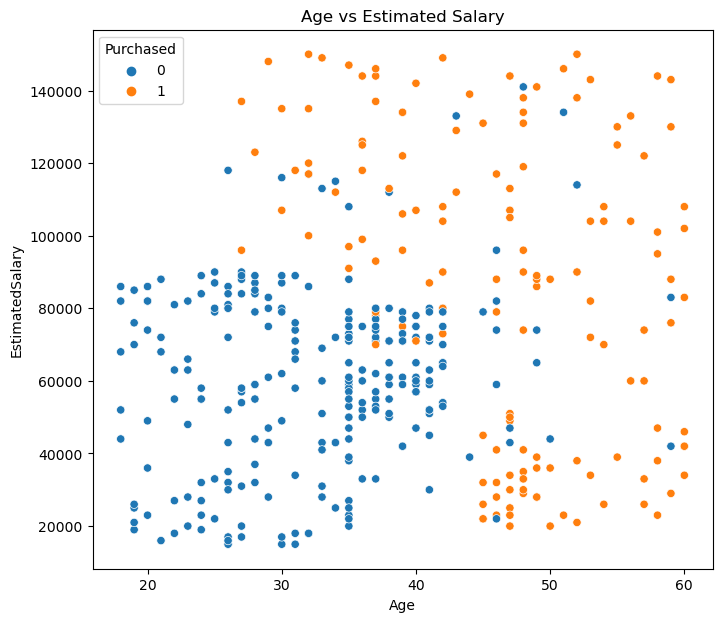

In [38]:
plt.figure(figsize=(8,7))

sns.scatterplot(
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    data=df
)


plt.title("Age vs Estimated Salary")

plt.show()